In [1]:
import torch
from sklearn.model_selection import train_test_split
import pandas as pd
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

In [2]:
torch.manual_seed(42)

In [3]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using Device : ",device)

Using Device :  cuda


In [4]:
df = pd.read_csv('fashion-mnist_train.csv')
df.head()

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,6,0,0,0,0,0,0,0,5,0,...,0,0,0,30,43,0,0,0,0,0
3,0,0,0,0,1,2,0,0,0,0,...,3,0,0,0,0,1,0,0,0,0
4,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


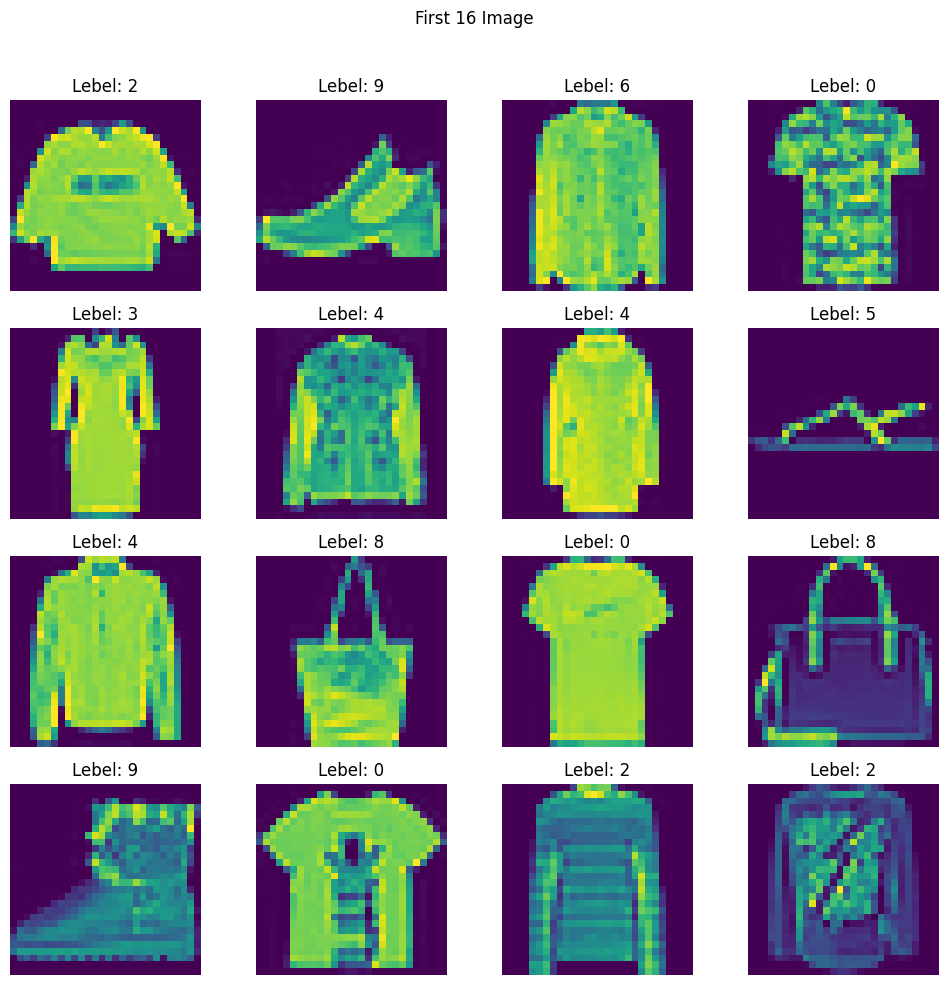

In [5]:
fig, axes =plt.subplots(4,4, figsize=(10,10))
fig.suptitle("First 16 Image")

for i,ax in enumerate(axes.flat):
    img = df.iloc[i,1:].values.reshape(28,28)
    ax.imshow(img)
    ax.axis('off')
    ax.set_title(f"Lebel: {df.iloc[i,0]}")

plt.tight_layout(rect=[0,0,1,0.96])

plt.show()

In [6]:
X = df.iloc[:,1:]
y = df.iloc[:, 0]

In [7]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [8]:
X_train = X_train/255.0
X_test = X_test/255.0

In [9]:
#create customdataset class
from torch.utils.data import DataLoader,Dataset
class CustomDataset(Dataset):
    def __init__(self,features,labels):
        self.features = torch.tensor(features.values,dtype=torch.float32)
        self.labels = torch.tensor(labels.values,dtype=torch.long)

    def __len__(self):
        return len(self.features)

    def __getitem__(self, index):
        return self.features[index],self.labels[index]

In [10]:
train_dataset = CustomDataset(X_train,y_train)

In [11]:
len(train_dataset)

48000

In [12]:
test_dataset = CustomDataset(X_test,y_test)

In [13]:
train_loader = DataLoader(train_dataset,batch_size=32,shuffle=True)
test_loader = DataLoader(test_dataset,batch_size=32,shuffle=False)

In [14]:
class MyNN(nn.Module):
    def __init__(self,num_featurs,):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(num_featurs,128),
            nn.BatchNorm1d(128),    #2 batch norm
            nn.ReLU(),
            nn.Dropout(p=0.3),     #1. Dropout
            nn.Linear(128,64),
            nn.BatchNorm1d(64),     #2 batch norm
            nn.ReLU(),
            nn.Linear(64,10)
        )

    def forward(self,x):
        return self.model(x)

In [15]:
learning_rate = 0.1
epochs = 10

In [16]:
model = MyNN(X_train.shape[1])
model = model.to(device)
criterian  = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(),lr=learning_rate,weight_decay=1e-4) # 3 . l2 regularization

In [17]:
for epoch in range(epochs):

    total_epoch_loss = 0
    for batch_featurs,batch_labels in train_loader:

        # move to gpu
        batch_featurs,batch_labels = batch_featurs.to(device),batch_labels.to(device)
        
        #forward pass
        outputs = model(batch_featurs)

        #calculate loss
        loss = criterian(outputs,batch_labels)

        #backpass
        optimizer.zero_grad()
        loss.backward()

        #update grads
        optimizer.step()
        total_epoch_loss = total_epoch_loss + loss.item()

    avg_loss = total_epoch_loss/len(train_loader)
    print(f'Epoch: {epoch+1}, Loss: {avg_loss}')

Epoch: 1, Loss: 0.568489661047856
Epoch: 2, Loss: 0.44614831056197485
Epoch: 3, Loss: 0.4124693043430646
Epoch: 4, Loss: 0.38909557735919953
Epoch: 5, Loss: 0.3710705645829439
Epoch: 6, Loss: 0.35946201940874256
Epoch: 7, Loss: 0.34941967187821865
Epoch: 8, Loss: 0.3416690384571751
Epoch: 9, Loss: 0.32757728730142116
Epoch: 10, Loss: 0.3241779361615578


In [18]:
model.eval()

MyNN(
  (model): Sequential(
    (0): Linear(in_features=784, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Linear(in_features=64, out_features=10, bias=True)
  )
)

In [21]:
total = 0
correct = 0

with torch.no_grad():

    for batch_featurs,batch_labels in test_loader:
        batch_featurs,batch_labels = batch_featurs.to(device),batch_labels.to(device)
        outputs = model(batch_featurs)

        _,predicted = torch.max(outputs,1)
        total = total + batch_labels.shape[0]
        correct = correct + (predicted == batch_labels).sum().item()

print(correct/total)

0.8845833333333334


In [22]:
total = 0
correct = 0

with torch.no_grad():

    for batch_featurs,batch_labels in train_loader:
        batch_featurs,batch_labels = batch_featurs.to(device),batch_labels.to(device)
        outputs = model(batch_featurs)

        _,predicted = torch.max(outputs,1)
        total = total + batch_labels.shape[0]
        correct = correct + (predicted == batch_labels).sum().item()

print(correct/total)

0.9107916666666667


- now over model not going overfit
